# Sparse Factor Design

Analyses the effect of increasing noise variance $\sigma^2$ on estimator performance for random sparse factor designs with $p=100$ and increasing sample size $n$. Produces Figure 1 of the paper.

For fixed $p=100$, a random prediction problem is drawn via:
$$
\begin{aligned}
\beta &\sim \mathrm{N}(0, I_p)\\
x_i &\sim \mathrm{Bernoulli}(1/p) \text{ i.i.d.}, \quad i = 1,\ldots,p
\end{aligned}
$$
Then for a designated number of repetitions, training datasets are drawn via $n$ i.i.d. samples:
$$
\begin{aligned}
x_{i,j} &\sim \mathrm{Bernoulli}(1/p) \text{ i.i.d.}, \quad i = 1,\ldots,p
y \mid x, \beta \sim \mathrm{N}(\beta^\top x,\, \sigma^2)
\end{aligned}
$$
Note: a single fixed $\beta$ is used across all repetitions per problem instance.

## Preview Experiment

In [1]:
import numpy as np
import problems
from experiments import Experiment, parameter_mean_squared_error, regularization_parameter, number_of_iterations, fitting_time
from matplotlib import pyplot as plt
from plotting import plot_metrics
from fastridge import RidgeEM, RidgeLOOCV

sigmas0 = [1.0, 3.0, 5.0]
rng = np.random.default_rng(1)
probs0 = [problems.random_sparse_factor_problem(100, sigma_eps=sig, rng=rng) for sig in sigmas0]
ns0 = [100, 200, 400, 800, 1600]

ridgeEM = RidgeEM(fit_intercept=False, normalize=False)
ridgeCV_fixed = RidgeLOOCV(alphas=np.logspace(-10, 10, 100, endpoint=True, base=10), fit_intercept=False, normalize=False)

estimators = [ridgeEM, ridgeCV_fixed]
est_names = ['EM', 'LOOCV']

exp0 = Experiment(probs0, estimators, ns0, 10, est_names, seed=1)
exp0.run()

<div><progress max="10" value="10"></progress> 100.00% [10/10 00:02&lt;00:00]</div>

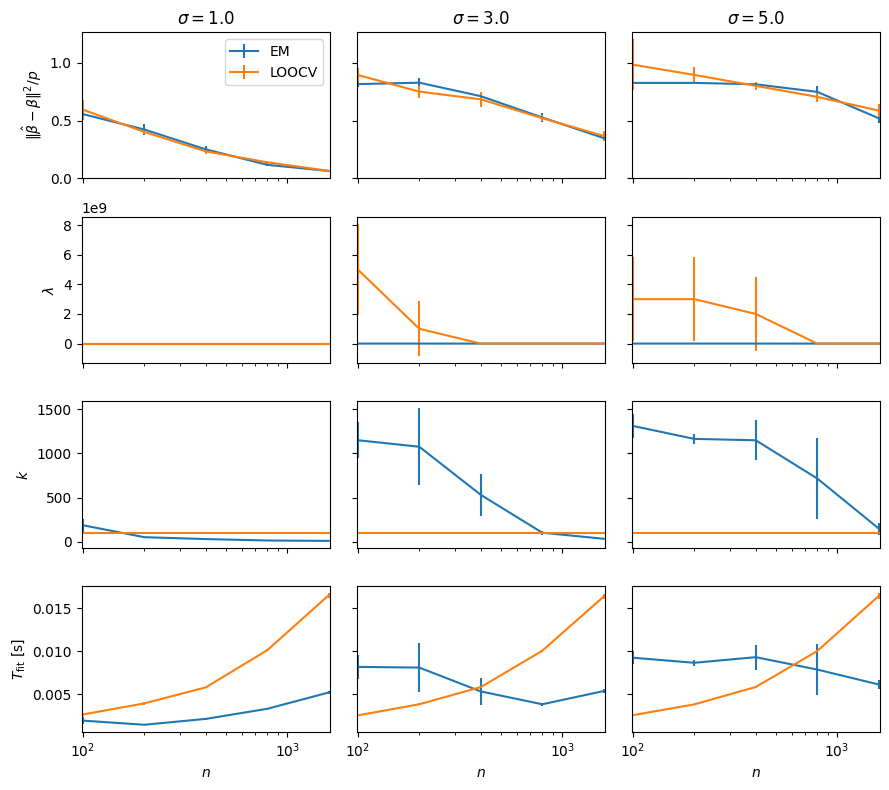

In [2]:
prob_idx0 = list(range(len(sigmas0)))
fig, axs = plot_metrics(exp0, [parameter_mean_squared_error, regularization_parameter, number_of_iterations, fitting_time], prob_idx=prob_idx0, figsize=(9, 8))
axs[0, 0].set_xscale('log')
for j in range(len(sigmas0)):
    axs[0, j].set_title(f'$\\sigma = {sigmas0[j]}$')
axs[0, 0].legend()
plt.show()

## Full Experiment

In [3]:
sigmas = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
rng1 = np.random.default_rng(1)
probs1 = [problems.random_sparse_factor_problem(100, sigma_eps=sig, rng=rng1) for sig in sigmas]
ns1 = [100, 150, 200, 300, 400, 600, 800, 1200, 1600, 2400, 3200, 4800, 6400, 9600, 12800]

exp1 = Experiment(probs1, estimators, ns1, 100, est_names, seed=1)
exp1.run()

<div><progress max="100" value="100"></progress> 100.00% [100/100 05:35&lt;00:00]</div>

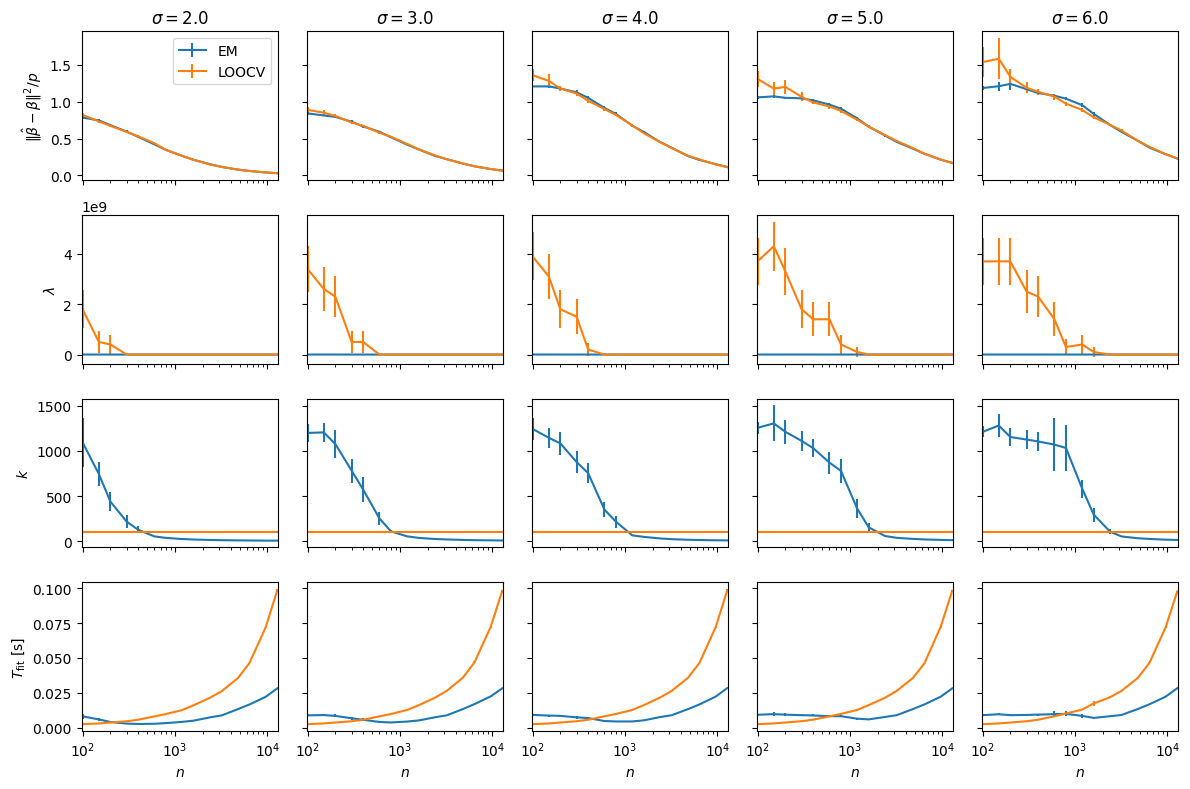

In [4]:
sigmas_idx_plot = [1, 2, 3, 4, 5]
fig, axs = plot_metrics(exp1, [parameter_mean_squared_error, regularization_parameter, number_of_iterations, fitting_time], prob_idx=sigmas_idx_plot, figsize=(12, 8))
axs[0, 0].set_xscale('log')
for j in range(len(sigmas_idx_plot)):
    axs[0, j].set_title(f'$\\sigma = {sigmas[sigmas_idx_plot[j]]}$')
axs[0, 0].legend()
plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig('../output/paper2023_figure1.pdf', dpi=600, bbox_inches="tight", pad_inches=0)
plt.show()